In [1]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch


words = open('names.txt', 'r').read().splitlines()

sorted_chars = sorted(list(set(''.join(words))))
enumerated = enumerate(sorted_chars)
char_to_idx = {char: idx + 1 for idx, char in enumerated}
char_to_idx['.'] = 0
idx_to_char = {idx: char for char, idx in char_to_idx.items()}

print(char_to_idx)
print(idx_to_char)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [10]:
a = torch.randn(1,2,3,4)
b = a.transpose(1, 2)

print(b.shape)
c = a.view(1,3,2,4)

print(c.shape)

print(torch.equal(b, c))

print(c.storage())

print(b.storage())



torch.Size([1, 3, 2, 4])
torch.Size([1, 3, 2, 4])
False
 0.24759283661842346
 -0.03855631873011589
 1.4059092998504639
 -0.32018744945526123
 -2.2889223098754883
 1.0190309286117554
 -0.6074780225753784
 -1.8917616605758667
 0.7793946266174316
 -0.848656415939331
 0.8221848011016846
 1.4453797340393066
 0.2936969995498657
 -1.0335625410079956
 0.041790250688791275
 -0.2581837475299835
 1.4189108610153198
 0.1883464902639389
 -0.487407922744751
 0.3503131568431854
 0.17490805685520172
 -0.8998402953147888
 -0.9976682066917419
 -0.27966466546058655
[torch.storage.TypedStorage(dtype=torch.float32, device=cpu) of size 24]
 0.24759283661842346
 -0.03855631873011589
 1.4059092998504639
 -0.32018744945526123
 -2.2889223098754883
 1.0190309286117554
 -0.6074780225753784
 -1.8917616605758667
 0.7793946266174316
 -0.848656415939331
 0.8221848011016846
 1.4453797340393066
 0.2936969995498657
 -1.0335625410079956
 0.041790250688791275
 -0.2581837475299835
 1.4189108610153198
 0.1883464902639389
 -

/tmp/ipykernel_1249/3847189042.py:11: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  print(c.storage())


In [37]:
ix = torch.randint(0, X.shape[0], (32,))
print(ix.shape)
print(ix)


print(X.shape[0])

torch.Size([32])
tensor([ 54568,  84653,  21483, 216712, 198160, 124331, 173086,  10923,  17920,
        191247,  38210,  42040,  10613, 178329, 213214,   4759, 180061, 207514,
        204729, 178866, 125859, 152392, 138857, 106135, 146009,  26909,   3021,
        170548, 198599,  76490,  20627, 215523])
228146


In [29]:
import random
def construct_dataset(words, block_size):
  X, Y = [], []
  for word in words:
    context = [0] * block_size
    for ch in word + '.':
      X.append(context)
      idx = char_to_idx[ch]
      Y.append(idx)
      context = context[1:] + [idx]
  return torch.tensor(X), torch.tensor(Y)

random.seed(42)
random.shuffle(words)
num_words = len(words)
training_size = int(0.8 * num_words)
validation_size = int(0.1 * num_words)
test_size = num_words - training_size - validation_size
block_size = 5

X_train, Y_train = construct_dataset(words[:training_size], block_size)
X_val, Y_val = construct_dataset(words[training_size:training_size + validation_size], block_size)
X_test, Y_test = construct_dataset(words[training_size + validation_size:], block_size)

print(X_train.shape, Y_train.shape)
print(X_val.shape, Y_val.shape)
print(X_test.shape, Y_test.shape)

torch.Size([182424, 5]) torch.Size([182424])
torch.Size([22836, 5]) torch.Size([22836])
torch.Size([22886, 5]) torch.Size([22886])


In [30]:
g = torch.Generator().manual_seed(2147483647)

embedding_dimension = 5
C = torch.randn((27, embedding_dimension), generator=g)
embeddings = C[X_train]

mat_dimension = block_size * embedding_dimension
invisible_layer_dimension = 300

W1 = torch.randn(mat_dimension, invisible_layer_dimension, generator=g)
b1 = torch.randn(invisible_layer_dimension, generator=g)
h = torch.tanh(embeddings.view(-1, mat_dimension) @ W1 + b1)

W2 = torch.randn((invisible_layer_dimension, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]
num_params = [sum(p.nelement() for p in parameters)]
print(num_params)
for p in parameters:
  p.requires_grad = True

[16062]


Streaming output truncated to the last 5000 lines.
2.08539080619812
2.3558242321014404
2.0095722675323486
2.157297372817993
2.175236701965332
2.0977489948272705
2.1345648765563965
2.3768699169158936
2.4072630405426025
2.264498233795166
2.149352788925171
1.9042319059371948
1.871890902519226
1.985302448272705
2.230701446533203
2.0663509368896484
2.0251505374908447
2.0575613975524902
1.8625388145446777
1.714892864227295
2.0306639671325684
2.670029878616333
1.765293002128601
1.83860445022583
2.221121311187744
2.1210777759552
2.111454486846924
2.322784662246704
2.080498695373535
2.2356116771698
2.049994468688965
2.30610990524292
2.0929996967315674
2.014603853225708
2.1456480026245117
2.178873062133789
2.2667438983917236
2.3268074989318848
1.892783761024475
2.2878353595733643
2.114116907119751
2.42108154296875
2.484208106994629
2.024623155593872
2.2288146018981934
2.2960023880004883
2.0077064037323
2.082761764526367
1.954850196838379
1.7787818908691406
1.9909411668777466
2.021440029144287
2.

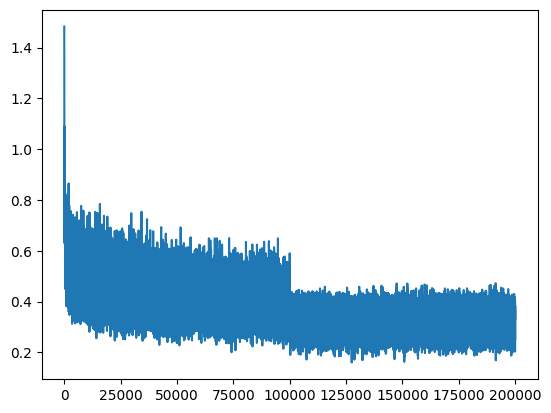

In [31]:
sample_size = 50
step = []
loss_values = []
for i in range(200000):
  ## sample random entries from dataset

  ix = torch.randint(0, X_train.shape[0], (sample_size,))

  emb = C[X_train[ix]]
  h = torch.tanh(emb.view(-1, mat_dimension) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Y_train[ix])
  print(loss.item())

  for p in parameters:
    p.grad = None
  loss.backward()

  learning_rate = 0.1 if i < 100000 else 0.01

  for p in parameters:
    p.data += -learning_rate * p.grad

  step.append(i)
  loss_values.append(loss.log10().item())

plt.plot(step, loss_values)
plt.show()

In [33]:
emb = C[X_val]
h = torch.tanh(emb.view(-1, mat_dimension) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_val)
print(loss.item())

2.156447649002075


In [32]:
emb = C[X_train]
h = torch.tanh(emb.view(-1, mat_dimension) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_train)
print(loss.item())

2.115220308303833


In [34]:
emb = C[X_test]
h = torch.tanh(emb.view(-1, mat_dimension) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_test)
print(loss.item())

2.1590096950531006


In [28]:
g = torch.Generator().manual_seed(2147483647 + 10)
for i in range(10):
  context = [0] * block_size
  word_idx = []
  while True:
    embedding = C[torch.tensor([context])]
    h = torch.tanh(embedding.view(1, -1) @ W1 + b1)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
    word_idx.append(ix)
    context = context[1:] + [ix]
    if ix == 0:
      break
  print(''.join(idx_to_char[i] for i in word_idx))

careah.
amelia.
khismlyn.
taty.
skanden.
jazonte.
amelynn.
kaqui.
nellana.
chaiir.
